# 4. nedēļa: Regresija
## Nepārtrauktas vērtības prognozēšana, vizualizācija un kļūdu metrikas

## 1. uzdevums. Sagatavo datus regresijai

### 1.1. Ielādē datu kopu

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 2. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


### 1.2. Izvēlies target un features

PageValues statistika:
count    1.233000e+04
mean     9.220344e-18
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


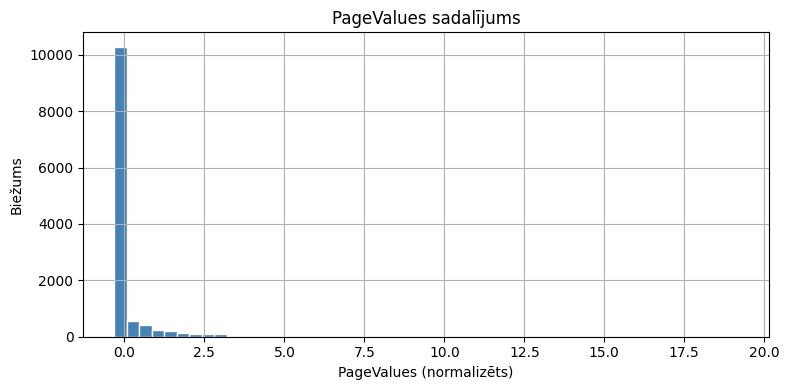

In [69]:
# Apskatām target mainīgo
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues (normalizēts)')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()

### 1.3. Sagatavo X un y

In [70]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
# (Revenue nedrīkst izmantot, jo tā ir "nākotnes" informācija — data leakage!)
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")

Features skaits: 26
Target: PageValues


### Kāpēc izņēmām Revenue un kas ir data leakage?

Revenue kļūst zināms tikai pēc sesijas beigām - tas ir rezultāts, nevis iemesls. Ja to iekļautu features, modelis trenēšanas laikā redzētu atbildi un testa metrikas būtu maldīgas. Data leakage ir tad, kad modelim trenēšanā ir pieejama informācija, kas reālā situācijā vēl nav zināma.

### 1.4. Treniņa/testa sadalījums

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# # Pareizi: fit tikai uz train datiem, lai testa dati neietekme skeilošanu
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


## 2. uzdevums. Uztrenē lineārās regresijas modeli

### 2.1. Modeļa trenēšana

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineārā regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Lineārā regresija: rezultāti ===
MSE:  0.9892
RMSE: 0.9946
MAE:  0.5009
R²:   0.0456


### 2.2. Metriku interpretācija

MSE kāpina kļūdas kvadrātā, tāpēc liela kļūda tiek sodīta daudz smagāk nekā maza kļūda. Tas nozīmē, ka modelis cenšas izvairīties no lielām kļūdām.

R^2 parāda, cik % datu variācijas modelis izskaidro. Vērtība tuva 1 ir laba, tuva 0 - modelis nav labāks par vienkāršu vidējo.

Modelis ir ļoti slikts - R^2 = 0.046, tas nozīmē, ka modelis izskaidro tikai 4.6% variācijas. PageValues sadalījumā ir ļoti daudz nullu un daži lieli izlecēji, kas lineārajai regresijai ir grūti.

## 3. uzdevums. Vizualizē prognozes

### 3.1. Faktiskās vs. prognozētās vērtības

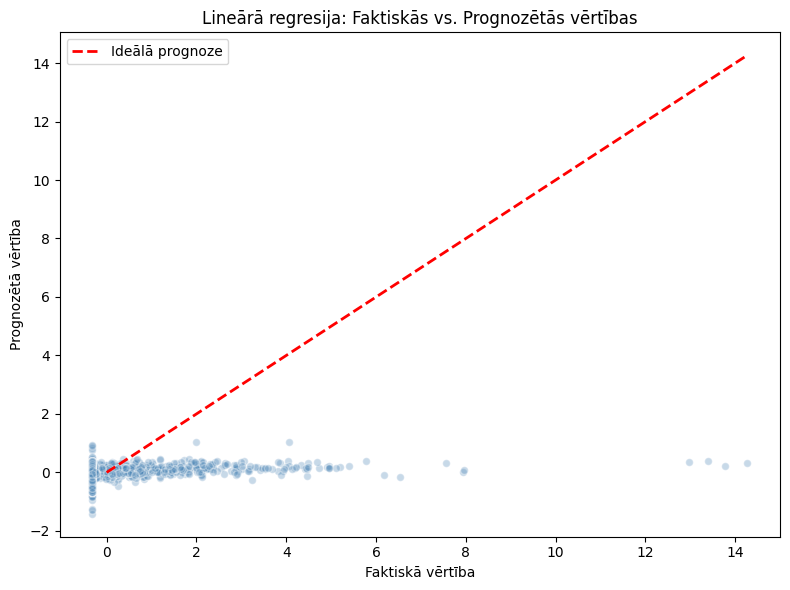

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineārā regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2. Atlikumu (residuals) analīze

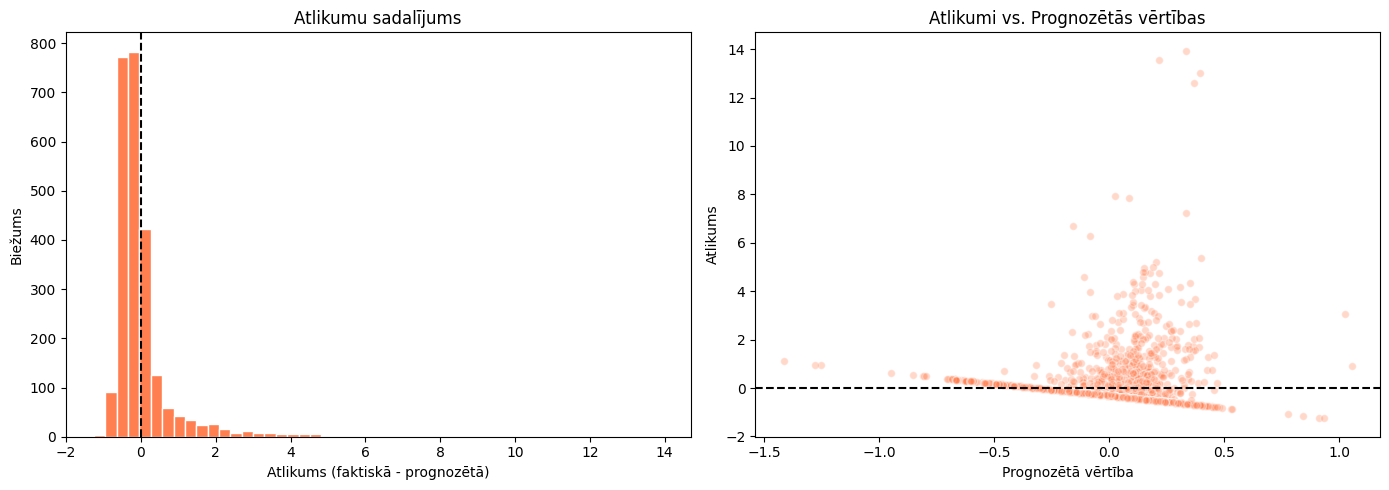

In [74]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

### 3.3. Vizualizāciju interpretācija

Punkti nav tuvu sarkanai līnijai - modelis kļūdās lielākajā daļā gadījumu, īpaši pie augstām faktiskajām vērtībām.

Atlikumi nav vienmērīgi sadalīti - 70% ir negatīvi, kas nozīmē, ka modelis vairumā gadījumu pārprognozē (prognozē pārāk augstas vērtības). Tas notiek, jo daudzi klienti ar PageValues = 0 tiek prognozēti nedaudz augstāk par nulli.

Vizualizācijas rāda, ka modelis nespēj labi prognozēt augstus PageValues - lielās pozitīvās kļūdas rodas tieši tur.

## 4. uzdevums. Uzlabo modeli

### 4.1. Pamēģini citu regresijas modeli

In [75]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# Metrikas
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor: rezultāti ===")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

=== Random Forest Regressor: rezultāti ===
RMSE: 0.9818
R²:   0.0699


### 4.2. Salīdzinājuma tabula

In [76]:
comparison = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Random Forest'],
    'RMSE': [rmse, rmse_rf],
    'R²': [r2, r2_rf]
})
print(comparison.to_string(index=False))

          Modelis     RMSE       R²
Lineārā regresija 0.994572 0.045556
    Random Forest 0.981814 0.069886


### 4.3. Vizuāls salīdzinājums

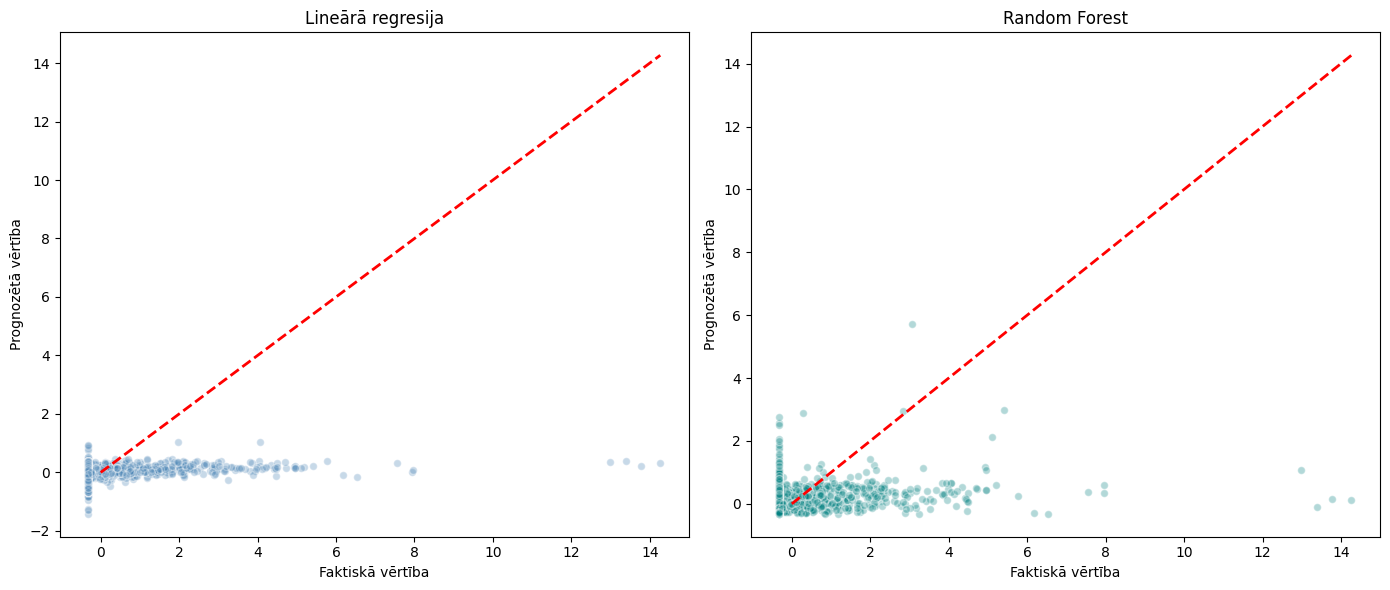

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, title, color in [
    (axes[0], y_pred, 'Lineārā regresija', 'steelblue'),
    (axes[1], y_pred_rf, 'Random Forest', 'teal')
]:
    ax.scatter(y_test, pred, alpha=0.3, color=color, edgecolors='white', s=30)
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')
    ax.set_title(title)

plt.tight_layout()
plt.show()

### 4.4. Secinājumi

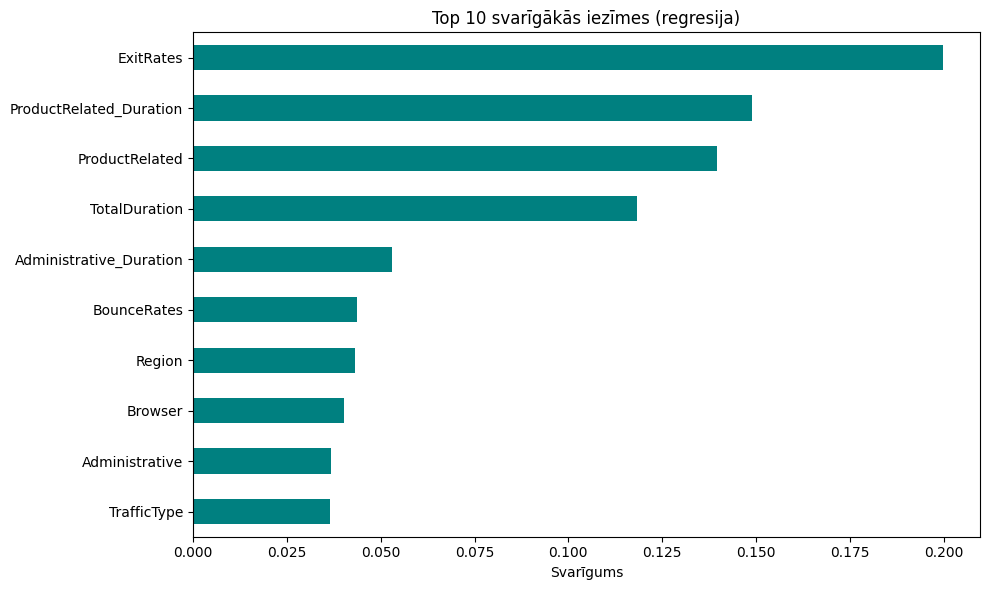

Top 5 svarīgākās iezīmes:
ExitRates                  0.1997
ProductRelated_Duration    0.1490
ProductRelated             0.1396
TotalDuration              0.1184
Administrative_Duration    0.0530
dtype: float64


In [78]:
# Feature importance
importances = rf_reg.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (regresija)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 svarīgākās iezīmes:")
print(feat_imp.head(5).round(4))

In [79]:
zero_share = (df['PageValues'] == df['PageValues'].min()).mean()
print(f"\nRindas ar PageValues = 0: {zero_share:.1%}")


Rindas ar PageValues = 0: 77.9%


Random Forest labāk prognozē PageValues - RMSE 0.982 vs 0.995 un R² 0.070 vs 0.046. Taču abi modeļi ir vāji - Random Forest izskaidro tikai 7% variācijas, tāpēc reālā biznesā šādas prognozes nav lietojamas.

Svarīgākās iezīmes pēc feature_importances_: ExitRates (0.20), ProductRelated_Duration (0.15), ProductRelated (0.14), TotalDuration (0.12). Klienti, kas mazāk atlec no lapām un pavada vairāk laika produktu lapās, parasti veic vērtīgākas sesijas.

Galvenais iemesls sliktajiem rezultātiem ir target sadalījums - 78% PageValues vērtību ir 0, kas padara prognozēšanu gandrīz neiespējamu ar šo pieeju. Labāks risinājums būtu sadalīt uzdevumu divās daļās: vispirms klasificēt vai PageValues > 0, tad regresēt tikai uz tiem klientiem.

## 5. uzdevums. Gala projekta plāns

# Mans gala projekts

## 1. Problēma
PageValues prognozēšana ir grūta, jo 78% vērtību ir 0. Risinājums - sadalīt uzdevumu divās daļās: vispirms klasificēt, vai klients vispār nonāk tuvu pirkumam (PageValues > 0), tad prognozēt faktisko vērtību tikai tiem klientiem.

## 2. Datu kopa
Online Shoppers Purchasing Intention - tā pati datu kopa no DataShop (12 330 sesijas, jau tīrīta week2).

## 3. ML pieeja
Divpakāpju pieeja:
1. solis: Klasifikācija - PageValues = 0 vai > 0 (RandomForest + GridSearchCV)
2. solis: Regresija - prognozēt PageValues tikai pozitīvajām rindām (RandomForest + CV)

## 4. Plānotās metrikas
- Klasifikācijai: F1 score, AUC-ROC
- Regresijai: RMSE, R² (sagaidāms daudz labāks nekā week4, jo nav 78% nullu)

## 5. Datu sagatavošana
Week2 tīrā datu kopa. Papildus izveidos bināro target: `PageValues > min_val`. Regresijas solim - filtrēs tikai rindas ar PageValues > 0.

Svarīga korekcija: week2 normalizēja arī PageValues kā feature, bet target mainīgais nav jānormalizē. Gala projektā izmantosim oriģinālo (nenormalizēto) PageValues kā y, bet features normalizēsim iekš Pipeline - tas dos interpretējamākus rezultātus un novērsīs šo metodisko kļūdu.

## 6. Plānotie modeļi
Pipeline(StandardScaler + RandomForestClassifier) ar GridSearchCV klasifikācijai. Pipeline(StandardScaler + RandomForestRegressor) ar cross-validation regresijai.

### 5.2. Pašnovērtējums

Problēma ir skaidri definēta - divpakāpju pieeja tieši risina week4 atklāto trūkumu ar 78% nullu.

Datu kopa ir piemērota - tā ir reāla, laba izmēra un jau tīrīta.

Metrikas ir izvēlētas apzināti - F1 klasifikācijai (nebalansētas klases), R² regresijai (sagaidāms uzlabojums salīdzinot ar week4).